# Gaussian Mixture on Full Data
**by Group 3**

## Installing and Importing Required Libraries

Java is installed for PySpark

In [2]:
!sudo yum install -y java-11-amazon-corretto-headless

Last metadata expiration check: 0:18:56 ago on Fri Jul 31 12:24:48 2026.
Package java-11-amazon-corretto-headless-1:11.0.31+11-1.amzn2023.x86_64 is already installed.
Dependencies resolved.
Nothing to do.
Complete!


In [3]:
import os
import glob

# Search for the installed Java directory
java_paths = glob.glob('/usr/lib/jvm/java-11*')

if java_paths:
    # Dynamically set the environment variable to the found path
    os.environ["JAVA_HOME"] = java_paths[0]
    print(f"JAVA_HOME successfully set to: {os.environ['JAVA_HOME']}")
else:
    print("Java not found. Did the yum install command work?")

JAVA_HOME successfully set to: /usr/lib/jvm/java-11-amazon-corretto.x86_64


Importing the necessary libraries for the model training

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

Setup a SparkSession

In [5]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
from pyspark import StorageLevel
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

spark = (
    SparkSession.builder
    .appName("KMeans-Sample-Data")
    .master("local[*]")
    .config("spark.jars.packages",
            "org.apache.hadoop:hadoop-aws:3.3.4,com.amazonaws:aws-java-sdk-bundle:1.12.262")
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
    .config("spark.hadoop.fs.s3a.aws.credentials.provider",
            "com.amazonaws.auth.InstanceProfileCredentialsProvider")
    .config("spark.driver.memory", "10g")
    .getOrCreate()
)

INPUT_PATH = "s3a://dat204m-project-g3/cleaned_data_final/"
OUTPUT_PATH = "s3a://dat204m-project-g3/sampled_eda_data/"


print("Spark ready:", spark.version)

:: loading settings :: url = jar:file:/home/ec2-user/anaconda3/envs/pytorch/lib/python3.10/site-packages/pyspark/jars/ivy-2.5.0.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /home/ec2-user/.ivy2/cache
The jars for the packages stored in: /home/ec2-user/.ivy2/jars
org.apache.hadoop#hadoop-aws added as a dependency
com.amazonaws#aws-java-sdk-bundle added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-e6b05d00-0124-4cf7-9d34-b90b7fd2fdec;1.0
	confs: [default]
	found org.apache.hadoop#hadoop-aws;3.3.4 in central
	found com.amazonaws#aws-java-sdk-bundle;1.12.262 in central
	found org.wildfly.openssl#wildfly-openssl;1.0.7.Final in central
:: resolution report :: resolve 314ms :: artifacts dl 42ms
	:: modules in use:
	com.amazonaws#aws-java-sdk-bundle;1.12.262 from central in [default]
	org.apache.hadoop#hadoop-aws;3.3.4 from central in [default]
	org.wildfly.openssl#wildfly-openssl;1.0.7.Final from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded

26/07/31 12:43:53 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


Spark ready: 3.3.0


Check if connection to s3 is stable

In [6]:
import boto3

s3 = boto3.client("s3")

try:
    print(s3.list_objects_v2(Bucket="dat204m-project-g3", MaxKeys=5))
except Exception as e:
    print(e)

{'ResponseMetadata': {'RequestId': '3MA70PZA2T59SDJP', 'HostId': 'nS51PGjAa5sG/nmB9U9+mAhDE25AIsle037H7RY7Ow6rsctlif5ZncHF9AKuVjdunap7zo+h8Wc=', 'HTTPStatusCode': 200, 'HTTPHeaders': {'x-amz-id-2': 'nS51PGjAa5sG/nmB9U9+mAhDE25AIsle037H7RY7Ow6rsctlif5ZncHF9AKuVjdunap7zo+h8Wc=', 'x-amz-request-id': '3MA70PZA2T59SDJP', 'date': 'Fri, 31 Jul 2026 12:44:00 GMT', 'x-amz-bucket-region': 'us-east-1', 'content-type': 'application/xml', 'transfer-encoding': 'chunked', 'server': 'AmazonS3'}, 'RetryAttempts': 0}, 'IsTruncated': True, 'Contents': [{'Key': 'athena-logs/Unsaved/2026/07/05/0948405c-ddc7-4308-a5ea-9e4150ecd730-manifest.csv', 'LastModified': datetime.datetime(2026, 7, 4, 16, 28, 45, tzinfo=tzlocal()), 'ETag': '"c90c48a2b97547599fca337a336b68a1"', 'ChecksumAlgorithm': ['SHA1'], 'ChecksumType': 'FULL_OBJECT', 'Size': 3240, 'StorageClass': 'STANDARD'}, {'Key': 'athena-logs/Unsaved/2026/07/05/0948405c-ddc7-4308-a5ea-9e4150ecd730.metadata', 'LastModified': datetime.datetime(2026, 7, 4, 16, 28

## Reading and Standardizing Full Data

Read the Parquet file of the feature engineered full data

In [7]:
EDA_DATA_PATH = "s3a://dat204m-project-g3/feature_engineered_full/"
features_df = spark.read.parquet(EDA_DATA_PATH)

26/07/31 12:44:00 WARN MetricsConfig: Cannot locate configuration: tried hadoop-metrics2-s3a-file-system.properties,hadoop-metrics2.properties


Show the schema of the sample data

In [8]:
features_df.printSchema()

root
 |-- product_id: string (nullable = true)
 |-- views: long (nullable = true)
 |-- likes: long (nullable = true)
 |-- cart: long (nullable = true)
 |-- offers: long (nullable = true)
 |-- buy_start: long (nullable = true)
 |-- buy_comp: long (nullable = true)
 |-- unique_users: long (nullable = true)
 |-- unique_sessions: long (nullable = true)
 |-- avg_price: double (nullable = true)
 |-- brand_name: string (nullable = true)
 |-- category_path: string (nullable = true)
 |-- cond_good: long (nullable = true)
 |-- cond_new: long (nullable = true)
 |-- cond_like_new: long (nullable = true)
 |-- cond_fair: long (nullable = true)
 |-- cond_poor: long (nullable = true)
 |-- cond_unknown: long (nullable = true)
 |-- log_views: double (nullable = true)
 |-- log_likes: double (nullable = true)
 |-- log_cart: double (nullable = true)
 |-- log_offers: double (nullable = true)
 |-- log_buy_start: double (nullable = true)
 |-- log_buy_comp: double (nullable = true)
 |-- log_users: double (null

Show the first five lines of the sample data

In [9]:
features_df.show(5)

26/07/31 12:44:06 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


[Stage 1:>                                                          (0 + 1) / 1]

+----------+-----+-----+----+------+---------+--------+------------+---------------+------------------+--------------+--------------------+---------+--------+-------------+---------+---------+------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------------+-----------------+------------------+------------------+------------------+-------------+----------------+
|product_id|views|likes|cart|offers|buy_start|buy_comp|unique_users|unique_sessions|         avg_price|    brand_name|       category_path|cond_good|cond_new|cond_like_new|cond_fair|cond_poor|cond_unknown|         log_views|         log_likes|          log_cart|        log_offers|     log_buy_start|      log_buy_comp|         log_users|      log_sessions|        log_price|    log_cond_good|      log_cond_new| log_cond_like_new|     log_cond_fair|log_cond_poor|log_cond_unknown|
+----------+-----+-----+----+------+

To reduce recomputation and improve performance, DataFrame is cached in memory and spills excess data to disk when needed

In [10]:
features_df = features_df.persist(StorageLevel.MEMORY_AND_DISK)

In [11]:
# Materialize cache
features_df.count()

1383996

Frequency Encoding is applied for categorical columns 'brand_name' and 'category_path' 

In [12]:
freq_cols = [
    "brand_name",
    "category_path"
]

features_encoded = features_df

for c in freq_cols:
    freq = (
        features_df.groupBy(c)
                   .count()
                   .withColumnRenamed("count", f"{c}_freq")
    )

    features_encoded = (
        features_encoded
        .join(freq, on=c, how="left")
    )

All numerical columns are combined into one single feature vector using VectorAssembler

In [13]:
numeric_features = [
    "log_views",
    "log_likes",
    "log_cart",
    "log_offers",
    "log_buy_comp",
    "log_buy_start",
    "log_users",
    "log_sessions",
    "log_price",
    "brand_name_freq",
    "category_path_freq",
    "log_cond_good",
    "log_cond_new",
    "log_cond_like_new",
    "log_cond_fair",
    "log_cond_poor",
    "log_cond_unknown"
]

assembler = VectorAssembler(
    inputCols=numeric_features,
    outputCol="features_raw"
)

Standard scaling is applied to prevent features with larger numerical ranges from dominating the clustering process

In [14]:
scaler = StandardScaler(
    inputCol="features_raw",
    outputCol="features",
    withMean=False,
    withStd=True
)

Pipeline is run to apply the vectorizing and standard scaling to the sample data

In [15]:
pipeline = Pipeline(stages=[
    assembler,
    scaler
])

In [16]:
pipeline_model = pipeline.fit(features_encoded)

In [17]:
# Transform encoded features into scaled feature vectors
transformed_df = pipeline_model.transform(features_encoded)

# Cache for faster repeated model training and evaluation
transformed_df.cache()

print(f"Number of records: {transformed_df.count():,}")

[Stage 21:====================================================> (194 + 4) / 200]

Number of records: 1,383,996


## Initial Model Training

A baseline Gaussian Mixture Model (GMM) is first trained using an initial set of hyperparameters. This provides an initial clustering of the products and establishes a reference point before performing hyperparameter tuning to identify a better-performing model.

In [18]:
# Importing Gaussian Mixture

from pyspark.ml.clustering import GaussianMixture

The model is initialized with five Gaussian components (`k = 5`) as the initial number of clusters. The Expectation-Maximization (EM) algorithm is allowed to run for a maximum of 20 iterations, while a fixed random seed is specified to ensure reproducible results.

In [18]:
# Initialize the Gaussian Mixture model
gmm = GaussianMixture(
    featuresCol="features",
    predictionCol="cluster",
    k=5,
    maxIter=20,
    seed=42
)

### Train the Initial Model

The initialized model is fitted to the transformed feature vectors. During training, the EM algorithm estimates the parameters of each Gaussian component, including the component means, covariance matrices, and mixture weights.

In [19]:
# Train the initial Gaussian Mixture Model
gmm_model = gmm.fit(transformed_df)

print("Initial Gaussian Mixture Model trained successfully.")

26/07/31 12:29:45 WARN LAPACK: Failed to load implementation from: com.github.fommil.netlib.NativeSystemLAPACK
26/07/31 12:29:45 WARN LAPACK: Failed to load implementation from: com.github.fommil.netlib.NativeRefLAPACK
26/07/31 12:29:45 WARN BLAS: Failed to load implementation from: com.github.fommil.netlib.NativeSystemBLAS
26/07/31 12:29:45 WARN BLAS: Failed to load implementation from: com.github.fommil.netlib.NativeRefBLAS


[Stage 162:===================================================> (194 + 4) / 200]

Initial Gaussian Mixture Model trained successfully.


### Generate Cluster Assignments

Once training is complete, the fitted model is used to assign each product to the Gaussian component with the highest posterior probability. The resulting cluster assignments will be used in the initial evaluation of the model.

In [20]:
# Generate cluster assignments
clustered_products = gmm_model.transform(transformed_df)

print(f"Total clustered products: {clustered_products.count():,}")

clustered_products.select(
    "product_id",
    "cluster"
).show(10, truncate=False)

Total clustered products: 1,383,996
+----------+-------+
|product_id|cluster|
+----------+-------+
|763_1003  |2      |
|20502_1003|2      |
|4107_1003 |3      |
|9273_1003 |2      |
|24159_1003|3      |
|25205_1003|2      |
|1935_1003 |2      |
|18643_1003|3      |
|7804_1003 |2      |
|17190_1003|2      |
+----------+-------+
only showing top 10 rows



The generated cluster column represents the predicted cluster membership for each product. These initial clustering results serve as the baseline model and will be evaluated using clustering performance metrics before proceeding with hyperparameter tuning.

## Initial Model Evaluation

The initial Gaussian Mixture Model is evaluated using multiple clustering validation metrics to assess the quality of the discovered clusters. Since clustering is an unsupervised learning task, these metrics measure cluster cohesion, separation, and model fit rather than prediction accuracy. The resulting performance will serve as the baseline for determining whether hyperparameter tuning can improve the clustering quality.

### Evaluate the Initial Model

In [21]:
from pyspark.ml.evaluation import ClusteringEvaluator
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
import numpy as np

The following metrics are computed:

- **Silhouette Score** – measures how well each observation fits within its assigned cluster.
- **Davies-Bouldin Index** – evaluates cluster separation and compactness. Lower values indicate better clustering.
- **Calinski-Harabasz Index** – measures the ratio of between-cluster dispersion to within-cluster dispersion. Higher values indicate better-defined clusters.
- **Average Log-Likelihood** – measures how well the Gaussian Mixture Model fits the observed data. Higher values indicate a better probabilistic fit.

In [22]:
# Evaluate Silhouette Score using Spark
evaluator = ClusteringEvaluator(
    predictionCol="cluster",
    featuresCol="features",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean"
)

silhouette = evaluator.evaluate(clustered_products)

# Convert Spark DataFrame to NumPy arrays for additional metrics
pdf = clustered_products.select("features", "cluster").toPandas()

X = np.vstack(pdf["features"].apply(lambda x: x.toArray()))
labels = pdf["cluster"].values

# Compute additional clustering metrics
dbi = davies_bouldin_score(X, labels)
chi = calinski_harabasz_score(X, labels)

# Compute Average Log-Likelihood
log_likelihood = gmm_model.summary.logLikelihood

### Initial Model Performance

In [23]:
print("Initial Gaussian Mixture Model Performance")
print("-" * 45)
print(f"Silhouette Score        : {silhouette:.4f}")
print(f"Davies-Bouldin Index    : {dbi:.4f}")
print(f"Calinski-Harabasz Index : {chi:.4f}")
print(f"Average Log-Likelihood  : {log_likelihood:.4f}")

Initial Gaussian Mixture Model Performance
---------------------------------------------
Silhouette Score        : 0.2832
Davies-Bouldin Index    : 2.8005
Calinski-Harabasz Index : 243402.7004
Average Log-Likelihood  : 1160914.6969


The initial Gaussian Mixture Model achieved a **Silhouette Score of 0.2832**, a **Davies–Bouldin Index of 2.8005**, a **Calinski–Harabasz Index of 243,402.70**, and an **Average Log-Likelihood of 1,160,914.70**. These results establish the baseline clustering performance of the model on the full dataset before hyperparameter tuning. The next stage evaluates different combinations of model parameters to determine whether better cluster separation, cluster compactness, and overall model fit can be achieved.

In [24]:
# Preserve baseline evaluation metrics
initial_silhouette = silhouette
initial_dbi = dbi
initial_chi = chi
initial_log_likelihood = log_likelihood

## Hyperparameter Tuning

Hyperparameter tuning is performed to identify the Gaussian Mixture Model configuration that produces the best clustering performance. Different combinations of the number of Gaussian components (`k`) and maximum EM iterations (`maxIter`) are evaluated using the same clustering validation metrics to determine the optimal model.

### Define the Hyperparameter Search Space

In [25]:
# Candidate hyperparameter values
k_values = [3, 4, 5, 6, 7]
max_iter_values = [20, 50]

A total of 10 model configurations are evaluated by varying the number of Gaussian components (`k = 3–7`) and the maximum number of EM iterations (`20` and `50`). For each configuration, the Silhouette Score, Davies–Bouldin Index, Calinski–Harabasz Index, and Average Log-Likelihood are computed to compare clustering performance across candidate models.

### Train and Evaluate Candidate Models

In [26]:
from pyspark.ml.evaluation import ClusteringEvaluator
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
import pandas as pd
import numpy as np

# Initialize evaluator
evaluator = ClusteringEvaluator(
    predictionCol="cluster",
    featuresCol="features",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean"
)

results = []

In [38]:
for k in k_values:
    for max_iter in max_iter_values:

        # Train candidate model
        model = GaussianMixture(
            featuresCol="features",
            predictionCol="cluster",
            k=k,
            maxIter=max_iter,
            seed=42
        ).fit(transformed_df)

        predictions = model.transform(transformed_df)

        # Compute Silhouette Score
        silhouette = evaluator.evaluate(predictions)

        # Convert to NumPy for additional metrics
        pdf = predictions.select("features", "cluster").toPandas()

        X = np.vstack(pdf["features"].apply(lambda x: x.toArray()))
        labels = pdf["cluster"].values

        dbi = davies_bouldin_score(X, labels)
        chi = calinski_harabasz_score(X, labels)
        log_likelihood = model.summary.logLikelihood

        results.append({
            "k": k,
            "maxIter": max_iter,
            "Silhouette Score": silhouette,
            "Davies-Bouldin Index": dbi,
            "Calinski-Harabasz Index": chi,
            "Average Log-Likelihood": log_likelihood
        })

### Compare Candidate Models

In [39]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Silhouette Score",
    ascending=False
).reset_index(drop=True)

results_df

,k,maxIter,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,Average Log-Likelihood
0,4,20,0.305819,2.665514,307185.675039,-3.078388e+03
1,4,20,0.305819,2.665514,307185.675039,-3.078388e+03
2,4,50,0.305555,2.673703,307754.291824,2.388028e+05
3,4,50,0.305555,2.673703,307754.291824,2.388028e+05
4,5,50,0.283744,2.717204,237259.288624,1.670146e+06
5,5,50,0.283744,2.717204,237259.288624,1.670146e+06
6,5,20,0.283162,2.800465,243402.700352,1.160915e+06
7,5,20,0.283162,2.800465,243402.700352,1.160915e+06
8,3,20,0.248728,2.021278,303798.132294,-3.460737e+06
9,3,20,0.248728,2.021278,303798.132294,-3.460737e+06


The table above summarizes the performance of each hyperparameter combination. The optimal model is selected by considering all evaluation metrics, with preference given to models that exhibit:

- Higher Silhouette Scores
- Lower Davies-Bouldin Indices
- Higher Calinski-Harabasz Indices
- Higher Average Log-Likelihood values

In [40]:
best_params = results_df.iloc[0]

print("Best Hyperparameters")
print("-" * 30)
print(best_params)

Best Hyperparameters
------------------------------
k                               4.000000
maxIter                        20.000000
Silhouette Score                0.305819
Davies-Bouldin Index            2.665514
Calinski-Harabasz Index    307185.675039
Average Log-Likelihood      -3078.387897
Name: 0, dtype: float64


The hyperparameter tuning results indicate that the configuration with **k = 4** and **maxIter = 20** achieved the best overall clustering performance. It obtained the **highest Silhouette Score (0.3058)** and the **lowest Davies–Bouldin Index (2.6655)** among all evaluated models, indicating better cluster separation and compactness. 

Although the configuration with **k = 4** and **maxIter = 50** produced a slightly higher Calinski–Harabasz Index (307,754.29), its Silhouette Score was marginally lower. Therefore, the Gaussian Mixture Model with 4 Gaussian components and 20 EM iterations was selected as the optimal model for the final clustering analysis.

## Train the Final Model

The optimal hyperparameters identified during the tuning process (**k = 4** and **maxIter = 20**) are used to train the final Gaussian Mixture Model. This configuration achieved the best overall clustering performance, with the highest Silhouette Score and the lowest Davies–Bouldin Index among the evaluated models. The resulting model is used for the final clustering analysis and interpretation.

### Retrieve the Best Hyperparameters

In [41]:
# Retrieve the best hyperparameters
best_k = int(best_params["k"])
best_max_iter = int(best_params["maxIter"])

print(f"Best number of Gaussian components (k): {best_k}")
print(f"Best maximum iterations: {best_max_iter}")

Best number of Gaussian components (k): 4
Best maximum iterations: 20


### Train the Final Gaussian Mixture Model

In [19]:
# Train the final Gaussian Mixture Model
final_gmm = GaussianMixture(
    featuresCol="features",
    predictionCol="cluster",
    k=4,
    maxIter=20,
    seed=42
)

final_gmm_model = final_gmm.fit(transformed_df)

print("Final Gaussian Mixture Model trained successfully.")

26/07/31 12:44:55 WARN LAPACK: Failed to load implementation from: com.github.fommil.netlib.NativeSystemLAPACK
26/07/31 12:44:55 WARN LAPACK: Failed to load implementation from: com.github.fommil.netlib.NativeRefLAPACK
26/07/31 12:44:55 WARN BLAS: Failed to load implementation from: com.github.fommil.netlib.NativeSystemBLAS
26/07/31 12:44:55 WARN BLAS: Failed to load implementation from: com.github.fommil.netlib.NativeRefBLAS


[Stage 162:===============================================>     (181 + 4) / 200]

Final Gaussian Mixture Model trained successfully.


The final Gaussian Mixture Model was successfully trained using the selected hyperparameters. Product records were assigned to one of the three Gaussian components, providing the basis for the final evaluation and cluster interpretation.

### Generate Final Cluster Assignments

In [20]:
# Generate final cluster assignments
final_clustered_products = final_gmm_model.transform(transformed_df)

print(f"Total clustered products: {final_clustered_products.count():,}")

final_clustered_products.select(
    "product_id",
    "cluster"
).show(10, truncate=False)

Total clustered products: 1,383,996
+----------+-------+
|product_id|cluster|
+----------+-------+
|763_1003  |3      |
|20502_1003|3      |
|4107_1003 |1      |
|9273_1003 |3      |
|24159_1003|1      |
|25205_1003|3      |
|1935_1003 |3      |
|18643_1003|1      |
|7804_1003 |3      |
|17190_1003|3      |
+----------+-------+
only showing top 10 rows



The final cluster assignments produced by the optimized Gaussian Mixture Model will be evaluated using the same clustering metrics. These results will then be analyzed to interpret the characteristics of each discovered cluster.

## Final Model Evaluation

The optimized Gaussian Mixture Model is evaluated using the same clustering validation metrics applied to the initial model. This allows for a direct comparison of clustering performance and verifies whether hyperparameter tuning improved the quality of the resulting clusters.

### Evaluate the Final Model

In [27]:
# Evaluate Silhouette Score using Spark
final_silhouette = evaluator.evaluate(final_clustered_products)

# Convert Spark DataFrame to NumPy arrays
final_pdf = final_clustered_products.select(
    "features",
    "cluster"
).toPandas()

X_final = np.vstack(final_pdf["features"].apply(lambda x: x.toArray()))
labels_final = final_pdf["cluster"].values

# Compute additional clustering metrics
final_dbi = davies_bouldin_score(X_final, labels_final)
final_chi = calinski_harabasz_score(X_final, labels_final)

# Compute Average Log-Likelihood
final_log_likelihood = final_gmm_model.summary.logLikelihood

### Final Model Performance

In [28]:
print("Final Gaussian Mixture Model Performance")
print("-" * 45)
print(f"Silhouette Score        : {final_silhouette:.4f}")
print(f"Davies-Bouldin Index    : {final_dbi:.4f}")
print(f"Calinski-Harabasz Index : {final_chi:.4f}")
print(f"Average Log-Likelihood  : {final_log_likelihood:.4f}")

Final Gaussian Mixture Model Performance
---------------------------------------------
Silhouette Score        : 0.3058
Davies-Bouldin Index    : 2.6655
Calinski-Harabasz Index : 307185.6750
Average Log-Likelihood  : -3078.3879


In [29]:
# Compare the initial and final Gaussian Mixture Model performance

comparison_df = pd.DataFrame({
    "Metric": [
        "Silhouette Score",
        "Davies-Bouldin Index",
        "Calinski-Harabasz Index",
        "Average Log-Likelihood"
    ],
    "Initial Model": [
        initial_silhouette,
        initial_dbi,
        initial_chi,
        initial_log_likelihood
    ],
    "Final Model": [
        final_silhouette,
        final_dbi,
        final_chi,
        final_log_likelihood
    ]
})

# Format the numeric columns to four decimal places
comparison_df["Initial Model"] = comparison_df["Initial Model"].map(lambda x: f"{x:.4f}")
comparison_df["Final Model"] = comparison_df["Final Model"].map(lambda x: f"{x:.4f}")

comparison_df

,Metric,Initial Model,Final Model
0,Silhouette Score,0.2832,0.3058
1,Davies-Bouldin Index,2.8005,2.6655
2,Calinski-Harabasz Index,243402.7004,307185.6750
3,Average Log-Likelihood,1160914.6969,-3078.3879


The evaluation metrics of the initial and final Gaussian Mixture Models are compared to quantify the impact of hyperparameter tuning. Improvements in the Silhouette Score, Davies–Bouldin Index, and Calinski–Harabasz Index indicate better cluster separation and compactness in the optimized model.

### Cluster Distribution

In [30]:
# Count the number of products in each cluster
cluster_distribution = (
    final_clustered_products
    .groupBy("cluster")
    .count()
    .orderBy("cluster")
)

cluster_distribution.show()

[Stage 390:================================================>    (184 + 4) / 200]

+-------+------+
|cluster| count|
+-------+------+
|      0|103723|
|      1|339308|
|      2| 89813|
|      3|851152|
+-------+------+



The cluster distribution is uneven across the four identified segments. **Cluster 3** contains the largest proportion of products (**851,152**, approximately **61.5%** of the dataset), followed by **Cluster 1** with **339,308** products (**24.5%**). **Cluster 0** and Cluster 2 are considerably smaller, containing **103,72**3 (**7.5%**) and **89,813** (**6.5%**) products, respectively. This distribution suggests that the majority of products share similar characteristics represented by Cluster 3, while the remaining clusters capture smaller, more distinct groups of products with different feature patterns.

### Summary Statistics by Cluster

In [23]:
final_clustered_products = final_clustered_products.withColumn(
    "total_conditions",
    F.col("cond_good") +
    F.col("cond_new") +
    F.col("cond_like_new") +
    F.col("cond_fair") +
    F.col("cond_poor") +
    F.col("cond_unknown")
)

In [24]:
final_clustered_products = (
    final_clustered_products
    .withColumn(
        "new_rate",
        F.when(
            F.col("total_conditions") > 0,
            F.col("cond_new") / F.col("total_conditions")
        ).otherwise(0)
    )
    .withColumn(
        "like_new_rate",
        F.when(
            F.col("total_conditions") > 0,
            F.col("cond_like_new") / F.col("total_conditions")
        ).otherwise(0)
    )
    .withColumn(
        "good_rate",
        F.when(
            F.col("total_conditions") > 0,
            F.col("cond_good") / F.col("total_conditions")
        ).otherwise(0)
    )
    .withColumn(
        "fair_rate",
        F.when(
            F.col("total_conditions") > 0,
            F.col("cond_fair") / F.col("total_conditions")
        ).otherwise(0)
    )
    .withColumn(
        "poor_rate",
        F.when(
            F.col("total_conditions") > 0,
            F.col("cond_poor") / F.col("total_conditions")
        ).otherwise(0)
    )
    .withColumn(
        "unknown_rate",
        F.when(
            F.col("total_conditions") > 0,
            F.col("cond_unknown") / F.col("total_conditions")
        ).otherwise(0)
    )
)

In [25]:
cluster_summary = (
    final_clustered_products
    .groupBy("cluster")
    .agg(
        # Cluster size
        F.count("*").alias("num_products"),

        # Customer engagement
        F.round(F.avg("views"), 2).alias("avg_views"),
        F.round(F.avg("likes"), 2).alias("avg_likes"),
        F.round(F.avg("cart"), 2).alias("avg_cart"),
        F.round(F.avg("buy_comp"), 2).alias("avg_purchases"),

        # Customer reach
        F.round(F.avg("unique_users"), 2).alias("avg_unique_users"),
        F.round(F.avg("unique_sessions"), 2).alias("avg_unique_sessions"),

        # Product characteristics
        F.round(F.avg("avg_price"), 2).alias("avg_price"),

        # Condition profile
        F.round(F.avg("new_rate"), 3).alias("pct_new"),
        F.round(F.avg("like_new_rate"), 3).alias("pct_like_new"),
        F.round(F.avg("good_rate"), 3).alias("pct_good"),
        F.round(F.avg("fair_rate"), 3).alias("pct_fair"),
        F.round(F.avg("poor_rate"), 3).alias("pct_poor"),
        F.round(F.avg("unknown_rate"), 3).alias("pct_unknown")
    )
    .orderBy("cluster")
)

cluster_summary.show(truncate=False)

[Stage 199:===================================================> (195 + 4) / 200]

+-------+------------+---------+---------+--------+-------------+----------------+-------------------+---------+-------+------------+--------+--------+--------+-----------+
|cluster|num_products|avg_views|avg_likes|avg_cart|avg_purchases|avg_unique_users|avg_unique_sessions|avg_price|pct_new|pct_like_new|pct_good|pct_fair|pct_poor|pct_unknown|
+-------+------------+---------+---------+--------+-------------+----------------+-------------------+---------+-------+------------+--------+--------+--------+-----------+
|0      |103723      |8418.29  |1494.43  |163.01  |9.41         |2647.88         |6491.68            |51.66    |0.312  |0.237       |0.384   |0.04    |0.026   |0.0        |
|1      |339308      |151.06   |17.63    |1.87    |0.0          |104.88          |141.16             |41.92    |0.323  |0.237       |0.358   |0.081   |0.0     |0.0        |
|2      |89813       |139.83   |19.9     |2.41    |0.58         |90.26           |128.43             |40.78    |0.46   |0.223       |0.

The average product prices are relatively similar across the four clusters, ranging from **40.78** to **51.66**. **Cluster 0** has the highest average price, while **Cluster 2** has the lowest. All clusters share the same minimum price of **1.00**, but **Cluster 3** contains the highest-priced products, with a maximum price of **3,650.00**. These results suggest that while price contributes to the clustering, other product features also play an important role in distinguishing the clusters.

In [36]:
from pyspark.sql.window import Window

# Count products in each category path within each cluster
category_counts = (
    final_clustered_products
    .groupBy("cluster", "category_path")
    .count()
)

# Rank category paths within each cluster
window = Window.partitionBy("cluster").orderBy(F.desc("count"))

top10_category_paths = (
    category_counts
    .withColumn("rank", F.row_number().over(window))
    .filter(F.col("rank") <= 10)
    .orderBy("cluster", "rank")
)

top10_category_paths.show(100, truncate=False)

[Stage 423:===================================================> (196 + 4) / 200]

+-------+-------------------------------------------------------------------+-----+----+
|cluster|category_path                                                      |count|rank|
+-------+-------------------------------------------------------------------+-----+----+
|0      |Women > Tops & blouses > T-shirts                                  |1168 |1   |
|0      |Women > Tops & blouses > Blouse                                    |1133 |2   |
|0      |Men > Tops > T-shirts                                              |1063 |3   |
|0      |Other > Other > Other                                              |871  |4   |
|0      |Vintage & collectibles > Antique > Collectibles                    |857  |5   |
|0      |Women > Dresses > Above knee, mini                                 |854  |6   |
|0      |Women > Tops & blouses > Tank Tops                                 |779  |7   |
|0      |Women > Shoes > Sandals                                            |762  |8   |
|0      |Toys & Colle

The category distribution analysis shows that product categories vary across clusters, suggesting that each cluster captures different product segments and customer interests. While fashion categories appear frequently across most clusters, some clusters show stronger representation from specialized categories such as beauty, electronics, collectibles, and home products.

**Cluster 0** is mainly dominated by fashion-related categories, including women's tops, blouses, dresses, men's t-shirts, and footwear such as sandals and boots. The presence of collectibles and action figures also suggests that this cluster contains a mix of common apparel products and some niche marketplace items. This indicates a broad consumer segment focused on everyday fashion and lifestyle products.

**Cluster 1** shows a stronger concentration of women's fashion categories, particularly blouses, t-shirts, dresses, and tank tops. Compared to Cluster 0, this cluster contains higher counts across apparel categories, suggesting a segment heavily focused on clothing products. The presence of home decor and collectibles indicates that it still includes a diverse range of marketplace listings.

**Cluster 2** represents a more specialized product segment, with top categories including skincare, body care, electronics, men's accessories, and plush collectibles. The stronger presence of beauty and electronics categories suggests that this cluster captures products associated with specific customer interests rather than general fashion demand.

**Cluster 3** represents the largest and broadest product segment, dominated by women's clothing categories such as blouses, t-shirts, dresses, and other women's apparel. The high frequency of fashion categories, along with collectibles and home decor, suggests that this cluster contains common marketplace products with broad customer appeal.

Overall, the category analysis indicates that **fashion products dominate most clusters**, particularly women's apparel such as tops, blouses, and dresses. However, smaller clusters capture more specialized product interests, including beauty, electronics, collectibles, and accessories. These differences suggest that clusters represent distinct customer preferences and marketplace behaviors, which can support more targeted recommendation strategies.

In [37]:
from pyspark.sql.window import Window

# Count products for each brand within each cluster
brand_counts = (
    final_clustered_products
    .groupBy("cluster", "brand_name")
    .count()
)

# Rank brands within each cluster
window = Window.partitionBy("cluster").orderBy(F.desc("count"))

top10_brands = (
    brand_counts
    .withColumn("rank", F.row_number().over(window))
    .filter(F.col("rank") <= 10)
    .select("cluster", "rank", "brand_name", "count")
    .orderBy("cluster", "rank")
)

top10_brands.show(100, truncate=False)

[Stage 434:===================================================> (194 + 4) / 200]

+-------+----+--------------------------------+-----+
|cluster|rank|brand_name                      |count|
+-------+----+--------------------------------+-----+
|0      |1   |None                            |2998 |
|0      |2   |Disney                          |1137 |
|0      |3   |Handmade                        |1129 |
|0      |4   |Unique Vintage                  |679  |
|0      |5   |Amazon                          |659  |
|0      |6   |Custom Variety Pack             |603  |
|0      |7   |Target                          |576  |
|0      |8   |Sanrio                          |555  |
|0      |9   |Boutique                        |472  |
|0      |10  |Nike                            |460  |
|1      |1   |Peanuts                         |323  |
|1      |2   |Lot                             |323  |
|1      |3   |BTS                             |320  |
|1      |4   |Harry Potter                    |313  |
|1      |5   |Warner Bros.                    |311  |
|1      |6   |Kate Spade    

The brand distribution analysis shows that brand preferences differ across clusters, suggesting that each product segment has different levels of brand influence and customer purchasing behavior. While unbranded, handmade, and seller-created listings appear frequently across clusters, some segments show stronger representation from recognizable entertainment, retail, and lifestyle brands.

**Cluster 0** is mainly represented by general marketplace and lifestyle brands, including Disney, Handmade, Unique Vintage, Amazon, Target, Sanrio, and Nike. This indicates a broad consumer segment where customers may prioritize product accessibility, affordability, and familiarity. The presence of both established brands and handmade products suggests that this cluster captures everyday products with wide customer appeal.

**Cluster 1** is strongly associated with entertainment and fandom-driven brands such as Peanuts, BTS, Harry Potter, Warner Bros., Disney Pixar, DC Comics, and Harley-Davidson. This suggests a collectible and niche-interest segment where customer decisions are likely influenced by emotional attachment, franchise popularity, and personal interests rather than only product functionality or price.

**Cluster 2** contains a combination of mass-market retailers and handmade or gift-oriented brands, including Amazon, Handmade, Target, Custom Variety Pack, Boutique, Disney, and Sanrio. This represents a segment where customers may value convenience, affordability, and variety. The coexistence of retail brands and customized products suggests opportunities for cross-selling between mainstream and personalized product offerings.

**Cluster 3** is characterized by customized, independent, and vintage-oriented brands, including Customized & Personalized, The Unbranded Brand, Walmart, Independent, Authentic Original Vintage Style, and Marvel. This indicates a more diverse long-tail marketplace segment where uniqueness, personalization, and seller identity play a larger role than traditional brand recognition.

Overall, the brand analysis highlights that clusters differ in how strongly brand identity influences customer behavior. Some clusters are driven by recognizable brands and fandom-based demand, while others are shaped by independent sellers, handmade products, and personalized offerings. These differences suggest that recommendation strategies should be adapted by segment: brand-based recommendations may be more effective for recognizable and collectible products, while discovery-based recommendations may better support unique and customized marketplace items.

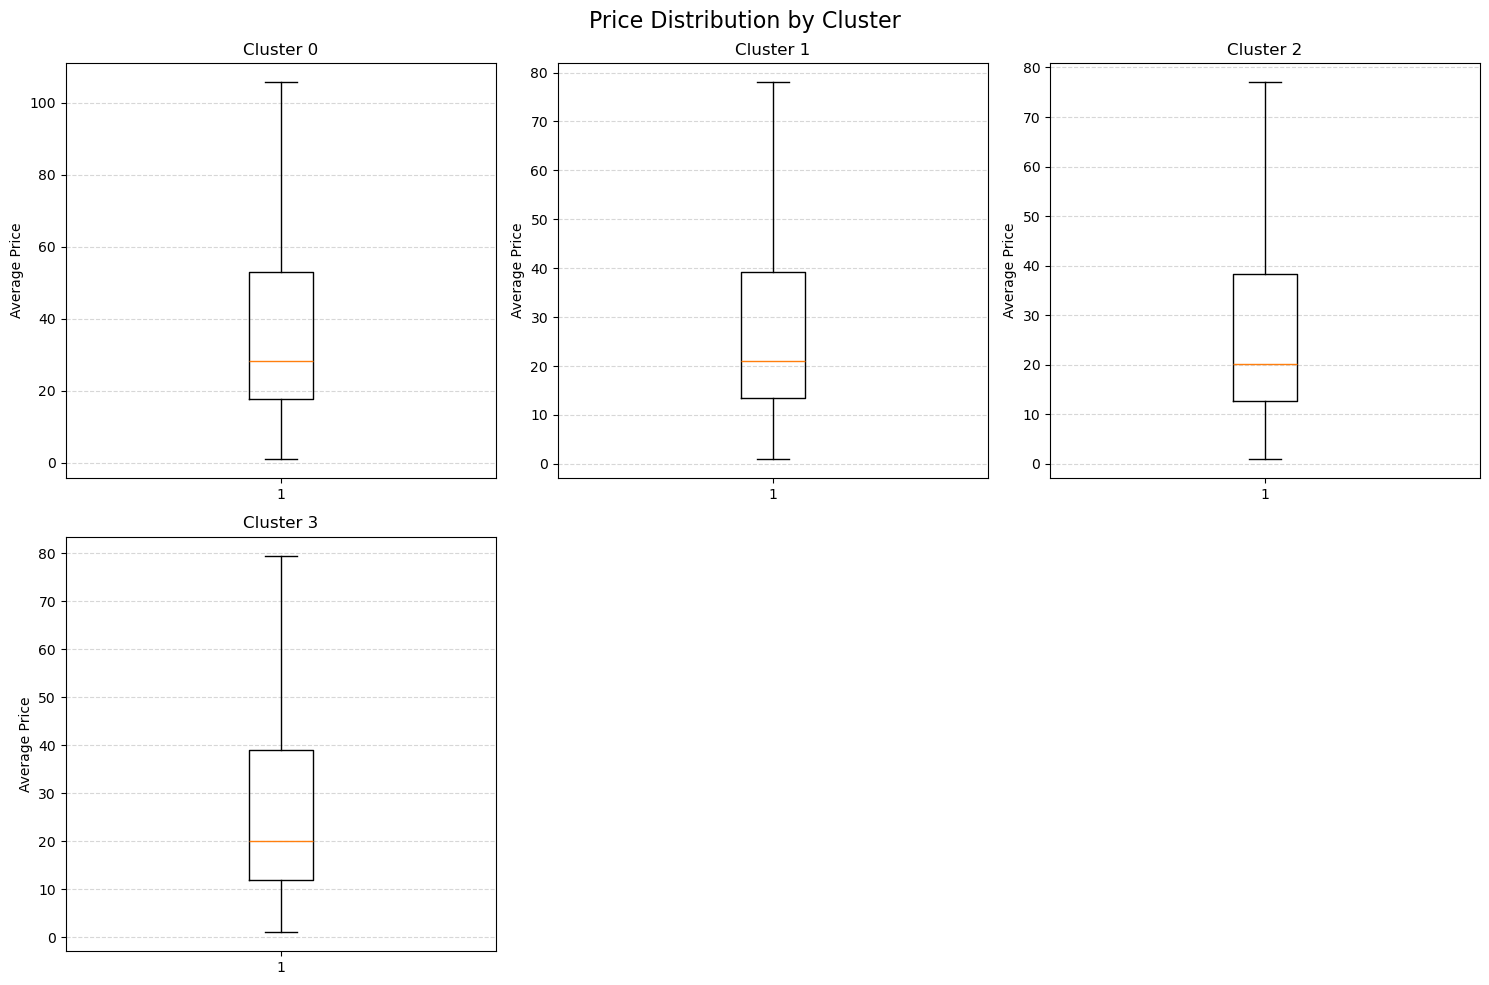

In [38]:
price_df = (
    final_clustered_products
    .select("cluster", "avg_price")
    .toPandas()
)

clusters = sorted(price_df["cluster"].unique())

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, cluster in enumerate(clusters):
    cluster_prices = price_df.loc[
        price_df["cluster"] == cluster,
        "avg_price"
    ].dropna()

    axes[i].boxplot(cluster_prices, showfliers=False)
    axes[i].set_title(f"Cluster {cluster}")
    axes[i].set_ylabel("Average Price")
    axes[i].grid(axis="y", linestyle="--", alpha=0.5)

# Hide the unused subplot (6th)
if len(clusters) < len(axes):
    for j in range(len(clusters), len(axes)):
        axes[j].axis("off")

plt.suptitle("Price Distribution by Cluster", fontsize=16)
plt.tight_layout()
plt.show()

The price distribution analysis shows that average product prices vary across clusters, indicating differences in product positioning, marketplace strategy, and customer purchasing behavior. While most clusters have relatively similar price ranges, some segments show wider price variation, suggesting a mix of low-cost and higher-value products.

**Cluster 0** shows the widest price distribution, with products ranging from low-cost items to higher-priced listings. The higher median price compared with other clusters suggests that this segment contains a diverse range of products, including both affordable marketplace items and higher-value products. This indicates a broad consumer segment where price sensitivity may vary depending on product type and brand influence.

**Cluster 1** has a lower median price and a relatively compact price range compared with Cluster 0. This suggests that products in this cluster are generally more affordable and consistently priced. The lower price variation may indicate a segment focused on accessible products where customers are more likely to consider affordability when making purchasing decisions.

**Cluster 2** shows a similar pricing pattern to Cluster 1, with a relatively moderate price range and lower median price. This suggests that this cluster represents mainstream products with competitive pricing. Customers in this segment may prioritize value, availability, and practicality over premium pricing.

**Cluster 3** has the lowest median price among the clusters but still shows considerable variation in product prices. The presence of both low-priced and higher-priced listings suggests a diverse segment containing independent sellers, customized products, and unique marketplace items. Pricing may depend more on product uniqueness and seller characteristics rather than standardized brand pricing.

Overall, the price analysis indicates that **clusters represent different product positioning strategies**. Cluster 0 captures a wider range of products with greater price diversity, while Clusters 1 and 2 represent more affordable and consistent pricing segments. Cluster 3 reflects a marketplace-driven segment where product uniqueness and seller variation contribute to differences in pricing. These differences suggest that recommendation and marketing strategies should consider price sensitivity, such as promoting value-based products for price-conscious customers and highlighting premium or unique products for higher-value segments.

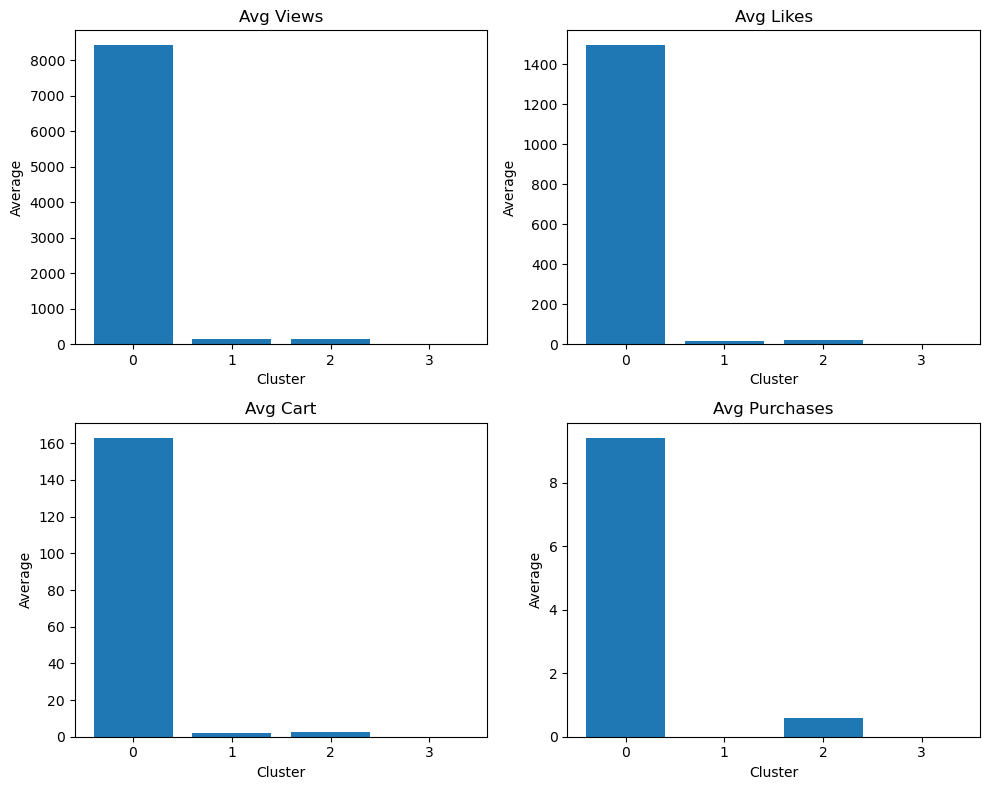

In [26]:
final_clustered_products_pdf = cluster_summary.toPandas()

features = ["avg_views", "avg_likes", "avg_cart", "avg_purchases"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

for ax, feature in zip(axes, features):
    ax.bar(final_clustered_products_pdf["cluster"].astype(str), final_clustered_products_pdf[feature])
    ax.set_title(feature.replace("_", " ").title())
    ax.set_xlabel("Cluster")
    ax.set_ylabel("Average")

plt.tight_layout()
plt.show()

### Overall Cluster Interpretation

## Cluster Interpretation

The optimized Gaussian Mixture Model identified **four** distinct product clusters based on the engineered feature set. The cluster distribution is uneven, with **Cluster 3** containing the majority of products, while **Clusters 0, 1, and 2** represent smaller product segments.

The summary statistics show that average product prices are relatively similar across the clusters, although **Cluster 3** contains the highest-priced products. This indicates that product price alone does not explain the clustering. Instead, the model grouped products using a combination of the engineered features included in the analysis.

Overall, the optimized Gaussian Mixture Model produced meaningful product segments that can support downstream tasks such as product segmentation, recommendation, and market analysis.

## PCA Visualization

Principal Component Analysis (PCA) was used to project the clustered data into two dimensions for visualization of the cluster distribution and separation.

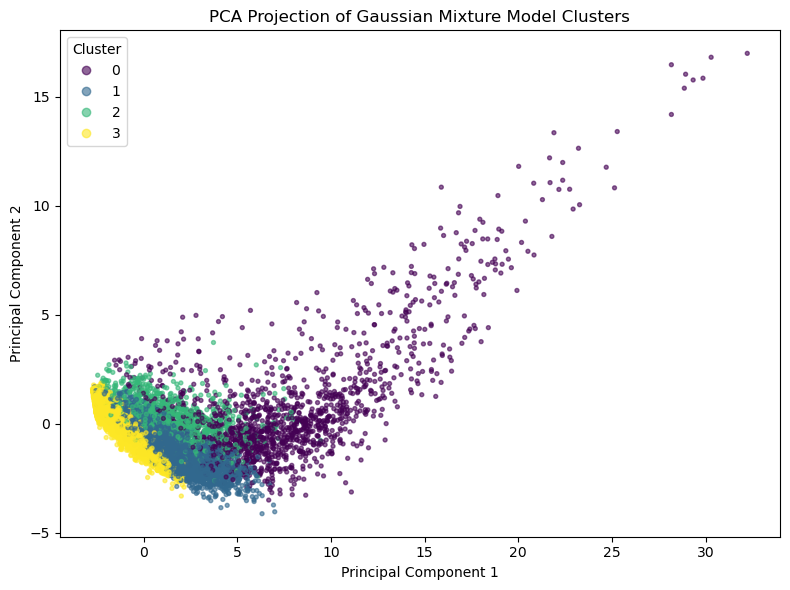

In [35]:
# Randomly sample 20,000 observations for visualization
sample_size = 20000
rng = np.random.RandomState(42)

idx = rng.choice(
    len(X_final),
    size=20000,
    replace=False
)

X_sample = X_final[idx]
labels_sample = labels_final[idx]

# Apply PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sample)

# Plot clusters
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=labels_sample,
    s=8,
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Projection of Gaussian Mixture Model Clusters")

plt.legend(*scatter.legend_elements(), title="Cluster")

plt.tight_layout()
plt.show()

### Interpretation

The PCA projection visualizes the four clusters identified by the optimized Gaussian Mixture Model. Some overlap is expected because GMM performs probabilistic clustering and PCA reduces the data to two dimensions.